#Prashna Prajapati

#2438462

#Part- II- Vision Tasks.

#Dataset: Intel Image Classification Dataset

#Part A : Designing and Analyzing Convolutional Neural Networks from Scratch.


## Install Required Package

In [ ]:
!pip install kagglehub

## Import Libraries

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Download Dataset

In [ ]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Dataset path:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset path: /kaggle/input/intel-image-classification


## Set Dataset Folders

In [ ]:
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir = os.path.join(path, "seg_test/seg_test")
pred_dir = os.path.join(path, "seg_pred/seg_pred")

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Prediction directory:", pred_dir)

Train directory: /kaggle/input/intel-image-classification/seg_train/seg_train
Test directory: /kaggle/input/intel-image-classification/seg_test/seg_test
Prediction directory: /kaggle/input/intel-image-classification/seg_pred/seg_pred


## Show Class Names

In [ ]:
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


#Data Understanding, Analysis, Visualization and Cleaning

### Dataset Description
The dataset used is the Intel Image Classification dataset, which contains images of natural scenes. The main goal of the dataset is to classify images into six categories: mountain, street, buildings, sea, forest, and glacier. This dataset is commonly used for image classification tasks using Convolutional Neural Networks (CNNs).

## Count Total Images and Class Distribution

In [ ]:
class_counts = []

for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts.append(len(os.listdir(class_path)))

distribution_df = pd.DataFrame({
    "Class": classes,
    "Number of Training Images": class_counts
})

total_train_images = sum(class_counts)
total_test_images = sum(len(os.listdir(os.path.join(test_dir, c))) for c in classes)

print("Total training images:", total_train_images)
print("Total testing images:", total_test_images)
print("Total images used for training/testing:", total_train_images + total_test_images)

distribution_df

Total training images: 14034
Total testing images: 3000
Total images used for training/testing: 17034


,Class,Number of Training Images
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


## Visualize Class Distribution

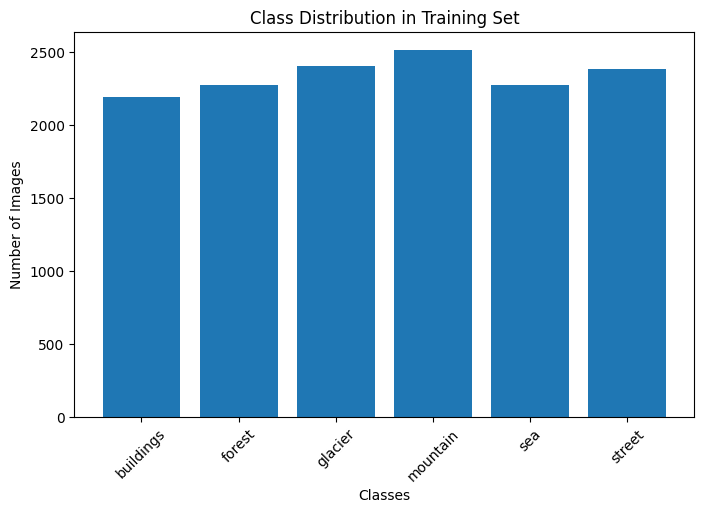

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(distribution_df["Class"], distribution_df["Number of Training Images"])
plt.title("Class Distribution in Training Set")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## Show Sample Images from Each Class

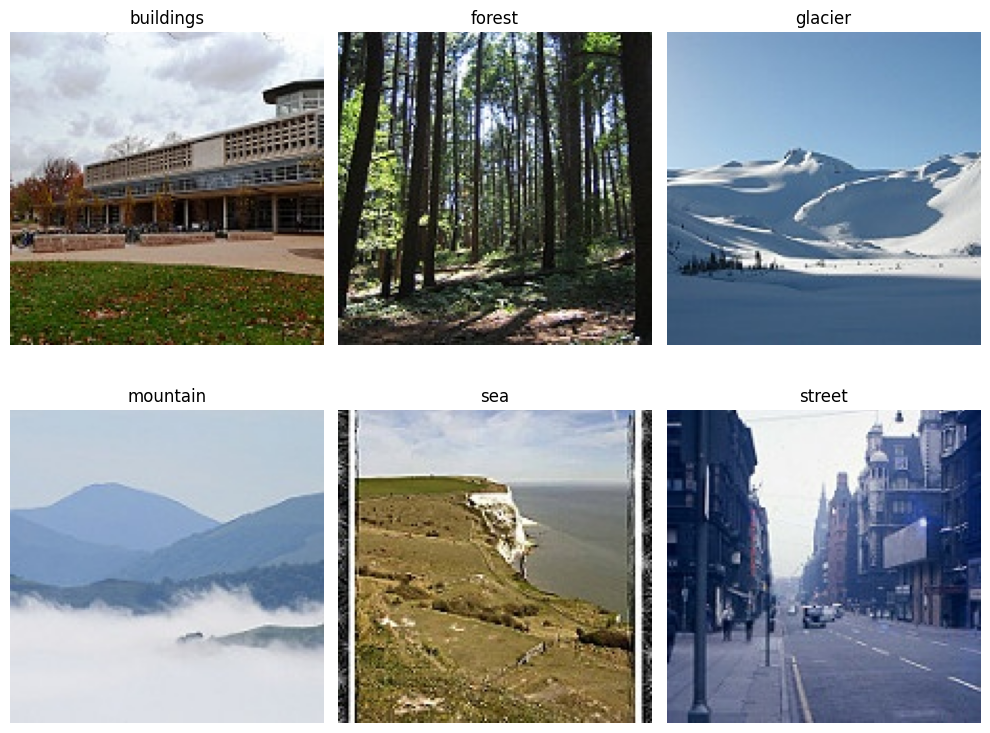

In [ ]:
plt.figure(figsize=(10, 8))

for i, c in enumerate(classes):
    img_path = os.path.join(train_dir, c, os.listdir(os.path.join(train_dir, c))[0])
    img = load_img(img_path, target_size=(150, 150))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing and Data Augmentation

For Part A, images are resized to 150 × 150 × 3. This is correct because the images are RGB images, so they have 3 color channels.

Preprocessing used:

- Resize images to 150 × 150
- Normalize pixel values using `rescale=1./255`
- Split training data into 80% training and 20% validation
- Use data augmentation such as rotation, zoom, horizontal flip, width shift, and height shift

In [ ]:
img_size = (150, 150)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## Visualize Augmented Images

Found 11230 images belonging to 6 classes.


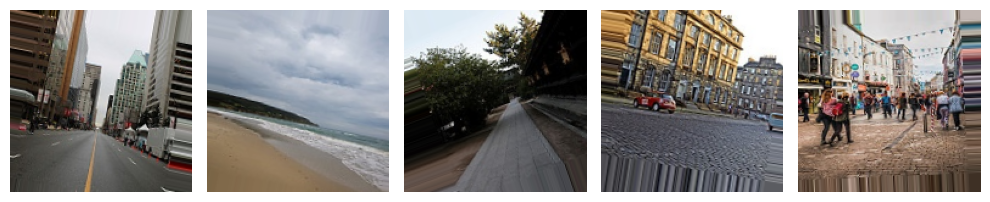

In [ ]:
aug_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=1,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

plt.figure(figsize=(10, 5))

for i in range(5):
    x_batch, y_batch = next(aug_generator)
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[0])
    plt.axis('off')

plt.tight_layout()
plt.show()

#Design, Train, and Evaluate a Baseline Model

## Build Baseline CNN Model

In [ ]:
baseline_model = Sequential(name="Baseline_CNN")

baseline_model.add(Input(shape=(150, 150, 3)))

baseline_model.add(Conv2D(32, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(2, 2))

baseline_model.add(Conv2D(64, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(2, 2))

baseline_model.add(Conv2D(128, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(2, 2))

baseline_model.add(Flatten())

baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(64, activation='relu'))
baseline_model.add(Dense(32, activation='relu'))

baseline_model.add(Dense(num_classes, activation='softmax'))

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838,886 (18.46 MB)

 Trainable params: 4,838,886 (18.46 MB)

 Non-trainable params: 0 (0.00 B)

## Train Baseline Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

end_time = time.time()
baseline_time = end_time - start_time

print("Baseline training time:", baseline_time, "seconds")

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 246ms/step - accuracy: 0.5683 - loss: 1.1033 - val_accuracy: 0.6084 - val_loss: 1.0267
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.6809 - loss: 0.8484 - val_accuracy: 0.7418 - val_loss: 0.7035
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.7377 - loss: 0.7151 - val_accuracy: 0.7850 - val_loss: 0.5924
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.7648 - loss: 0.6439 - val_accuracy: 0.8035 - val_loss: 0.5463
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 218ms/step - accuracy: 0.7811 - loss: 0.6095 - val_accuracy: 0.8192 - val_loss: 0.5088
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 218ms/step - accuracy: 0.7991 - loss: 0.5552 - val_accuracy: 0.8285 - val_loss: 0.4777
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 223ms/step - accuracy: 0.8177 - loss: 0.5136 - val_accuracy: 0.8242 - val_loss: 0.4883
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.8219 - loss: 0

## Plot Baseline Training Curves

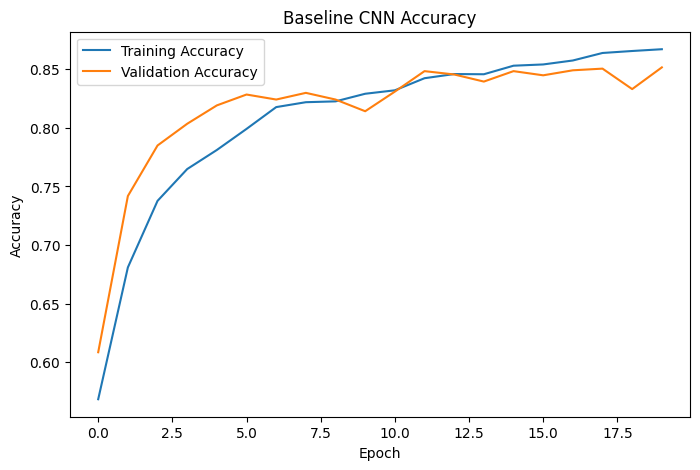

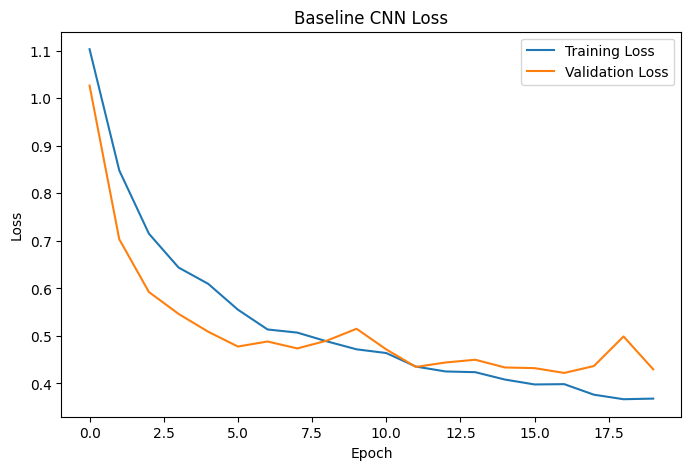

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluate Baseline Model

In [ ]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(test_generator)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8373 - loss: 0.4410
Baseline Test Loss: 0.44101783633232117
Baseline Test Accuracy: 0.8373333215713501


## Baseline Classification Report and Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
Baseline Classification Report:
              precision    recall  f1-score   support

   buildings       0.77      0.88      0.82       437
      forest       0.98      0.93      0.95       474
     glacier       0.80      0.83      0.81       553
    mountain       0.84      0.69      0.76       525
         sea       0.80      0.84      0.82       510
      street       0.86      0.87      0.86       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



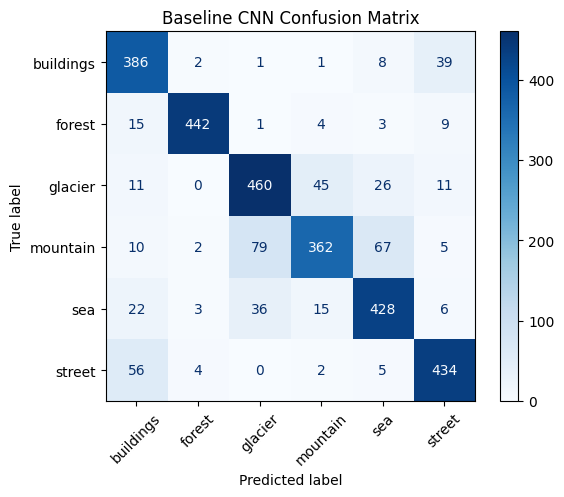

In [ ]:
test_generator.reset()
y_pred_baseline = baseline_model.predict(test_generator)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("Baseline Classification Report:")
print(classification_report(y_true, y_pred_baseline_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_baseline_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

## Baseline Inference on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


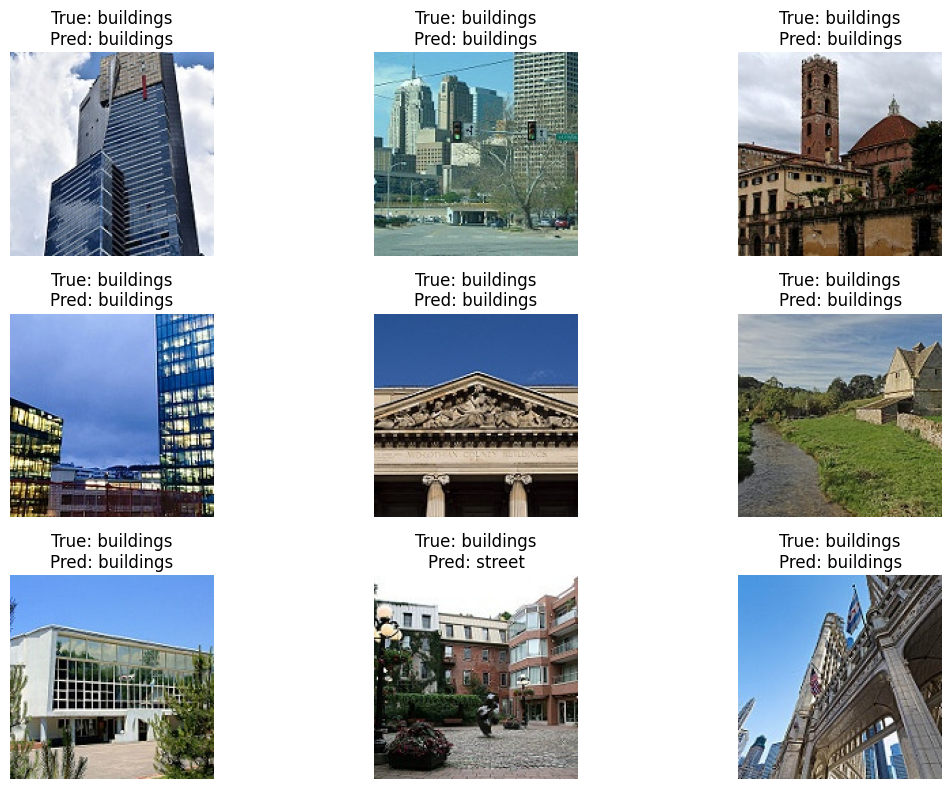

In [ ]:
test_generator.reset()
x_batch, y_batch = next(test_generator)
predictions = baseline_model.predict(x_batch)

plt.figure(figsize=(12, 8))

for i in range(min(9, len(x_batch))):
    true_label = class_names[np.argmax(y_batch[i])]
    predicted_label = class_names[np.argmax(predictions[i])]

    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Deeper Architecture with Regularization Layer

## Build Deeper CNN Model

In [ ]:
deep_model = Sequential(name="Deeper_CNN")

deep_model.add(Input(shape=(150,150,3)))

deep_model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(MaxPooling2D(2,2))

deep_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(MaxPooling2D(2,2))
deep_model.add(Dropout(0.2))

deep_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(MaxPooling2D(2,2))
deep_model.add(Dropout(0.3))

deep_model.add(GlobalAveragePooling2D())

deep_model.add(Dense(256, activation='relu'))
deep_model.add(Dropout(0.3))

deep_model.add(Dense(128, activation='relu'))
deep_model.add(Dropout(0.2))

deep_model.add(Dense(num_classes, activation='softmax'))

deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


deep_model.summary()


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 355,494 (1.36 MB)

 Trainable params: 354,598 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
early_stop_deep = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train Deeper CNN Model

In [ ]:
start_time = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop_deep]
)

end_time = time.time()

deep_time = end_time - start_time
print("Deep Model Training Time:", deep_time, "seconds")

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 264ms/step - accuracy: 0.5523 - loss: 1.1336 - val_accuracy: 0.2279 - val_loss: 2.9436
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.6612 - loss: 0.8722 - val_accuracy: 0.6676 - val_loss: 0.8853
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.7159 - loss: 0.7608 - val_accuracy: 0.6872 - val_loss: 0.8695
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.7370 - loss: 0.7026 - val_accuracy: 0.7450 - val_loss: 0.7136
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.7604 - loss: 0.6530 - val_accuracy: 0.7807 - val_loss: 0.6120
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 243ms/step - accuracy: 0.7788 - loss: 0.6113 - val_accuracy: 0.8110 - val_loss: 0.5208
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.7865 - loss: 0.5755 - val_accuracy: 0.7361 - val_loss: 0.7296
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 238ms/step - accuracy: 0.7992 - loss: 

## Plot Deeper CNN Training Curves

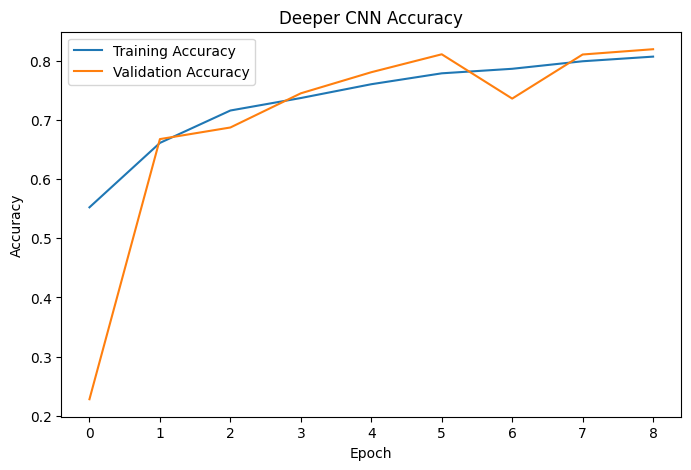

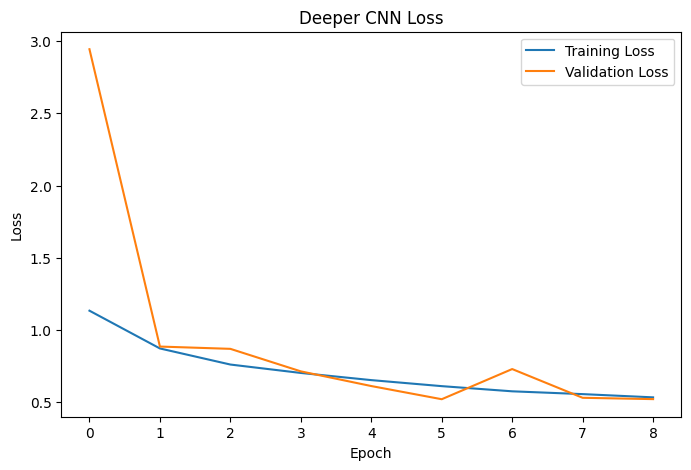

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['accuracy'], label='Training Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['loss'], label='Training Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluate Deeper CNN Model

In [ ]:
deep_loss, deep_accuracy = deep_model.evaluate(test_generator)

print("Deeper Model Test Loss:", deep_loss)
print("Deeper Model Test Accuracy:", deep_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8117 - loss: 0.5285
Deeper Model Test Loss: 0.5285323262214661
Deeper Model Test Accuracy: 0.8116666674613953


## Deeper CNN Classification Report and Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step
Deeper CNN Classification Report:
              precision    recall  f1-score   support

   buildings       0.80      0.76      0.78       437
      forest       0.83      0.99      0.90       474
     glacier       0.78      0.82      0.80       553
    mountain       0.79      0.75      0.77       525
         sea       0.83      0.78      0.80       510
      street       0.84      0.78      0.81       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



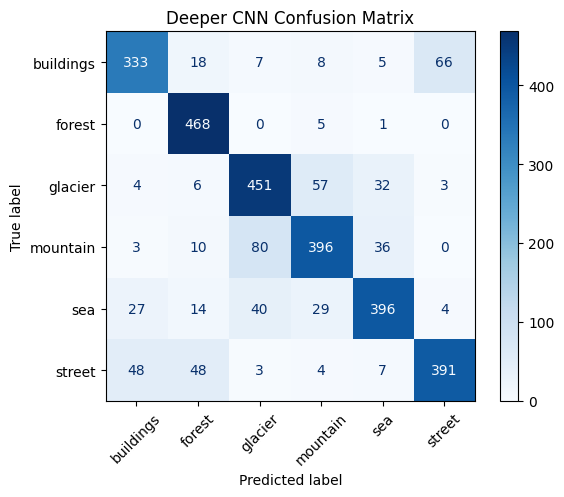

In [ ]:
test_generator.reset()
y_pred_deep = deep_model.predict(test_generator)
y_pred_deep_classes = np.argmax(y_pred_deep, axis=1)

print("Deeper CNN Classification Report:")
print(classification_report(y_true, y_pred_deep_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_deep_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Deeper CNN Confusion Matrix")
plt.show()

# Experimentation and Comparative Analysis

## Baseline vs Deeper Model Comparison

In [ ]:
comparison_table = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN"],
    "Test Accuracy": [baseline_accuracy, deep_accuracy],
    "Test Loss": [baseline_loss, deep_loss],
    "Training Time (seconds)": [baseline_time, deep_time]
})

comparison_table

,Model,Test Accuracy,Test Loss,Training Time (seconds)
0,Baseline CNN,0.837333,0.441018,1545.085514
1,Deeper CNN,0.811667,0.528532,785.220705


## Compare Training and Validation Accuracy

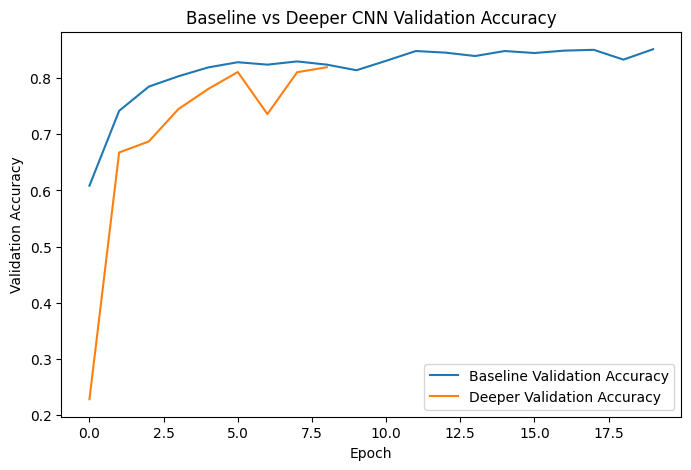

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Deeper Validation Accuracy')
plt.title('Baseline vs Deeper CNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

## Optimizer Analysis: SGD vs Adam

The deeper model above uses Adam. The following model uses the same deeper architecture but trains with SGD.

In [ ]:
sgd_model = Sequential(name="Deeper_CNN_SGD")

sgd_model.add(Input(shape=(150, 150, 3)))

sgd_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(MaxPooling2D(2, 2))
sgd_model.add(Dropout(0.25))

sgd_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(MaxPooling2D(2, 2))
sgd_model.add(Dropout(0.25))

sgd_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
sgd_model.add(BatchNormalization())
sgd_model.add(MaxPooling2D(2, 2))
sgd_model.add(Dropout(0.30))

sgd_model.add(GlobalAveragePooling2D())
sgd_model.add(Dense(256, activation='relu'))
sgd_model.add(Dropout(0.50))
sgd_model.add(Dense(128, activation='relu'))
sgd_model.add(Dropout(0.30))
sgd_model.add(Dense(num_classes, activation='softmax'))

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_model.summary()

Model: "Deeper_CNN_SGD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 536,358 (2.05 MB)

 Trainable params: 535,206 (2.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
start_time = time.time()

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

end_time = time.time()
sgd_time = end_time - start_time

sgd_loss, sgd_accuracy = sgd_model.evaluate(test_generator)

print("SGD Model Training Time:", sgd_time)
print("SGD Test Loss:", sgd_loss)
print("SGD Test Accuracy:", sgd_accuracy)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 112s 288ms/step - accuracy: 0.4948 - loss: 1.2281 - val_accuracy: 0.3930 - val_loss: 1.5233
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 238ms/step - accuracy: 0.5978 - loss: 0.9975 - val_accuracy: 0.5699 - val_loss: 1.0182
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.6674 - loss: 0.8764 - val_accuracy: 0.5777 - val_loss: 1.1915
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.3940 - loss: 1.5280
SGD Model Training Time: 280.0791127681732
SGD Test Loss: 1.527997374534607
SGD Test Accuracy: 0.39399999380111694


## Adam vs SGD Comparison

In [ ]:
optimizer_comparison = pd.DataFrame({
    "Optimizer": ["Adam", "SGD"],
    "Test Accuracy": [deep_accuracy, sgd_accuracy],
    "Test Loss": [deep_loss, sgd_loss],
    "Training Time (seconds)": [deep_time, sgd_time]
})

optimizer_comparison

,Optimizer,Test Accuracy,Test Loss,Training Time (seconds)
0,Adam,0.811667,0.528532,785.220705
1,SGD,0.394000,1.527997,280.079113


## Ablation Study: Remove Dropout

This model keeps Batch Normalization but removes Dropout. This helps check whether Dropout improved the deeper model or not.

In [ ]:
no_dropout_model = Sequential(name="Deeper_CNN_No_Dropout")

no_dropout_model.add(Input(shape=(150, 150, 3)))

no_dropout_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(MaxPooling2D(2, 2))

no_dropout_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(MaxPooling2D(2, 2))

no_dropout_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
no_dropout_model.add(BatchNormalization())
no_dropout_model.add(MaxPooling2D(2, 2))

no_dropout_model.add(GlobalAveragePooling2D())
no_dropout_model.add(Dense(256, activation='relu'))
no_dropout_model.add(Dense(128, activation='relu'))
no_dropout_model.add(Dense(num_classes, activation='softmax'))

no_dropout_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

no_dropout_model.summary()

Model: "Deeper_CNN_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,358 (2.05 MB)

 Trainable params: 535,206 (2.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Train No-Dropout Model

In [ ]:
start_time = time.time()

history_no_dropout = no_dropout_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

end_time = time.time()
no_dropout_time = end_time - start_time

no_dropout_loss, no_dropout_accuracy = no_dropout_model.evaluate(test_generator)

print("No Dropout Training Time:", no_dropout_time)
print("No Dropout Test Loss:", no_dropout_loss)
print("No Dropout Test Accuracy:", no_dropout_accuracy)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 255ms/step - accuracy: 0.6343 - loss: 0.9476 - val_accuracy: 0.2133 - val_loss: 2.4154
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.7404 - loss: 0.6979 - val_accuracy: 0.7250 - val_loss: 0.7257
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 243ms/step - accuracy: 0.7768 - loss: 0.6077 - val_accuracy: 0.6637 - val_loss: 1.1552
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.2177 - loss: 2.4014
No Dropout Training Time: 278.03971338272095
No Dropout Test Loss: 2.401376247406006
No Dropout Test Accuracy: 0.21766667068004608


## Ablation Study Comparison

In [ ]:
ablation_table = pd.DataFrame({
    "Model": ["Deeper CNN With Dropout", "Deeper CNN Without Dropout"],
    "Test Accuracy": [deep_accuracy, no_dropout_accuracy],
    "Test Loss": [deep_loss, no_dropout_loss],
    "Training Time (seconds)": [deep_time, no_dropout_time]
})

ablation_table

,Model,Test Accuracy,Test Loss,Training Time (seconds)
0,Deeper CNN With Dropout,0.811667,0.528532,785.220705
1,Deeper CNN Without Dropout,0.217667,2.401376,278.039713


#  Part B: Fine-Tuning a Pre-Trained Model

This section uses ResNet50, a pre-trained CNN model trained on ImageNet. For ResNet50, images are resized to **224 × 224 × 3**, which is correct for this transfer learning part.

## Create ResNet50 Data Generators

In [ ]:
resnet_img_size = (224, 224)

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=resnet_img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

resnet_validation_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=resnet_img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

resnet_test_generator = resnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=resnet_img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## Load and Adapt ResNet50 Model

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs, outputs, name="ResNet50_Transfer_Learning")

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train ResNet50 Feature Extraction Model

In [ ]:
start_time = time.time()

history_resnet = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

end_time = time.time()
resnet_feature_time = end_time - start_time

print("ResNet50 feature extraction training time:", resnet_feature_time, "seconds")

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 202s 546ms/step - accuracy: 0.8513 - loss: 0.4121 - val_accuracy: 0.8894 - val_loss: 0.2925
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 515ms/step - accuracy: 0.8937 - loss: 0.2982 - val_accuracy: 0.9155 - val_loss: 0.2512
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 189s 538ms/step - accuracy: 0.8981 - loss: 0.2808 - val_accuracy: 0.9141 - val_loss: 0.2484
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.9069 - loss: 0.2621 - val_accuracy: 0.9155 - val_loss: 0.2343
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 514ms/step - accuracy: 0.9068 - loss: 0.2524 - val_accuracy: 0.9173 - val_loss: 0.2240
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 520ms/step - accuracy: 0.9104 - loss: 0.2480 - val_accuracy: 0.9237 - val_loss: 0.2237
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 506ms/step - accuracy: 0.9110 - loss: 0.2392 - val_accuracy: 0.9230 - val_loss: 0.2202
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 504ms/step - accuracy: 0.9138 -

## Plot ResNet50 Feature Extraction Curves

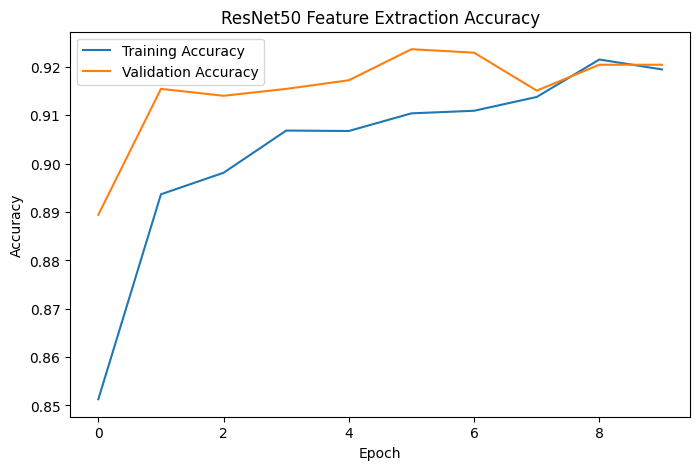

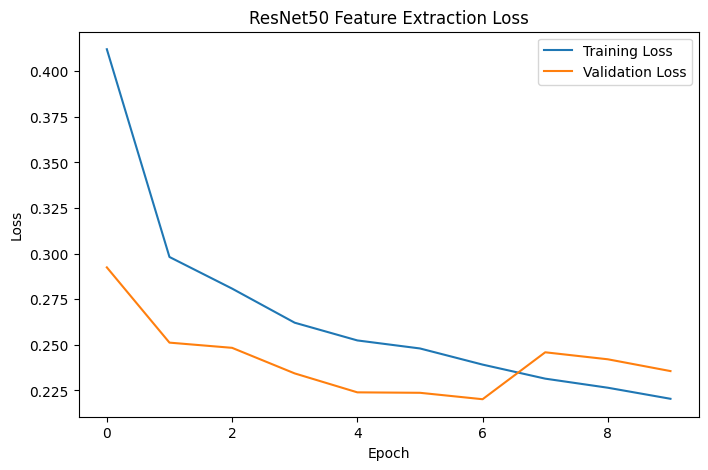

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Feature Extraction Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Feature Extraction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Fine-Tune ResNet50

Only the last layers of the ResNet50 base are unfrozen. A lower learning rate is used to avoid damaging the pre-trained weights.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 14,976,262 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

## Train Fine-Tuned ResNet50 Model

In [ ]:
start_time = time.time()

history_resnet_finetune = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

end_time = time.time()
resnet_finetune_time = end_time - start_time

total_resnet_time = resnet_feature_time + resnet_finetune_time

print("ResNet50 fine-tuning time:", resnet_finetune_time, "seconds")
print("Total ResNet50 training time:", total_resnet_time, "seconds")

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 215s 559ms/step - accuracy: 0.9012 - loss: 0.2682 - val_accuracy: 0.9233 - val_loss: 0.2151
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 513ms/step - accuracy: 0.9224 - loss: 0.2138 - val_accuracy: 0.9230 - val_loss: 0.2154
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 522ms/step - accuracy: 0.9294 - loss: 0.1973 - val_accuracy: 0.9276 - val_loss: 0.2026
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 516ms/step - accuracy: 0.9358 - loss: 0.1770 - val_accuracy: 0.9269 - val_loss: 0.2089
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 182s 518ms/step - accuracy: 0.9403 - loss: 0.1604 - val_accuracy: 0.9308 - val_loss: 0.1945
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 514ms/step - accuracy: 0.9444 - loss: 0.1489 - val_accuracy: 0.9351 - val_loss: 0.1866
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 516ms/step - accuracy: 0.9487 - loss: 0.1426 - val_accuracy: 0.9312 - val_loss: 0.1978
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 513ms/step - accuracy: 0.9546 -

## Evaluate Fine-Tuned ResNet50 Model

In [ ]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(resnet_test_generator)

print("ResNet50 Test Loss:", resnet_loss)
print("ResNet50 Test Accuracy:", resnet_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.9380 - loss: 0.1737
ResNet50 Test Loss: 0.1736621856689453
ResNet50 Test Accuracy: 0.9380000233650208


## ResNet50 Classification Report and Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step
ResNet50 Classification Report:
              precision    recall  f1-score   support

   buildings       0.96      0.94      0.95       437
      forest       0.99      0.99      0.99       474
     glacier       0.92      0.85      0.88       553
    mountain       0.87      0.92      0.90       525
         sea       0.96      0.98      0.97       510
      street       0.94      0.96      0.95       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



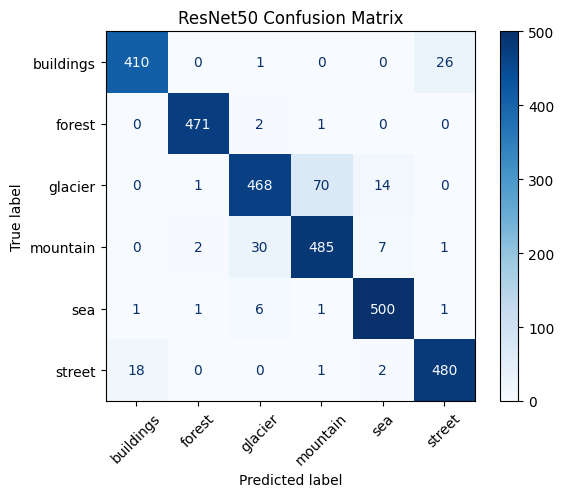

In [ ]:
resnet_test_generator.reset()
y_pred_resnet = resnet_model.predict(resnet_test_generator)
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)
y_true_resnet = resnet_test_generator.classes
resnet_class_names = list(resnet_test_generator.class_indices.keys())

print("ResNet50 Classification Report:")
print(classification_report(y_true_resnet, y_pred_resnet_classes, target_names=resnet_class_names))

cm = confusion_matrix(y_true_resnet, y_pred_resnet_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=resnet_class_names)
disp.plot(xticks_rotation=45, cmap = "Blues")
plt.title("ResNet50 Confusion Matrix")
plt.show()

## Final Model Comparison

In [ ]:
final_comparison_table = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN", "ResNet50 Transfer Learning"],
    "Test Accuracy": [baseline_accuracy, deep_accuracy, resnet_accuracy],
    "Test Loss": [baseline_loss, deep_loss, resnet_loss],
    "Training Time (seconds)": [baseline_time, deep_time, total_resnet_time]
})

final_comparison_table

,Model,Test Accuracy,Test Loss,Training Time (seconds)
0,Baseline CNN,0.837333,0.441018,1545.085514
1,Deeper CNN,0.811667,0.528532,785.220705
2,ResNet50 Transfer Learning,0.938000,0.173662,3488.936656
